In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [10]:
import pandas as pd
df = pd.read_csv("../data/vanilla_convertibles_data_enhanced.csv")

In [11]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["price_normalized"])

X = df.drop(columns=["price_convertible", "price_normalized", "redemption"])
y = df[["price_normalized"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)


In [ ]:
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing._data import BOUNDS_THRESHOLD
from scipy.stats import norm

scaler_X = QuantileTransformer(output_distribution="normal", random_state=42)
scaler_y = QuantileTransformer(output_distribution="normal", random_state=42)

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)

# Replace ±inf with sklearn's natural boundary: ppf at BOUNDS_THRESHOLD ≈ ±5.1993
_lower = norm.ppf(BOUNDS_THRESHOLD)
_upper = norm.ppf(1 - BOUNDS_THRESHOLD)
X_train = np.clip(X_train, _lower, _upper)
X_val = np.clip(X_val, _lower, _upper)
X_test = np.clip(X_test, _lower, _upper)
y_train = np.clip(y_train, _lower, _upper)
y_val = np.clip(y_val, _lower, _upper)

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

In [14]:
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = y_train.shape[1]

WIDTH = 528
DEPTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

BATCH_SIZE = 1024
LR = 1e-3
EPOCHS = 200
PATIENCE = 10

SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Input: {INPUT_DIM} | Output: {OUTPUT_DIM}")

Device: cpu | Input: 24 | Output: 1


In [15]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE)

In [ ]:
from architectures.nn_build import build_mlp

results = []

for depth in DEPTHS:
    print(f"\n{'='*40}")
    print(f"Depth={depth}, Width={WIDTH}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, WIDTH, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"depth": depth, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=1, Width=528
  Epoch  10 | Train: nan | Val: nan | Wait: 10
  Early stop at epoch 10
  Best Val Loss: inf

Depth=2, Width=528
  Epoch   1 | Train: 0.029944 | Val: 0.007671 | Wait: 0
  Epoch   4 | Train: 0.007735 | Val: 0.002974 | Wait: 0
  Epoch   6 | Train: 0.006691 | Val: 0.002882 | Wait: 0
  Epoch   8 | Train: 0.005834 | Val: 0.001726 | Wait: 0
  Epoch  10 | Train: 0.005334 | Val: 0.002989 | Wait: 2
  Early stop at epoch 18
  Best Val Loss: 0.001726

Depth=3, Width=528
  Epoch   1 | Train: 0.036884 | Val: 0.012717 | Wait: 0
  Epoch   2 | Train: 0.010379 | Val: 0.007663 | Wait: 0
  Epoch   4 | Train: 0.006539 | Val: 0.004980 | Wait: 0
  Epoch   5 | Train: 0.006457 | Val: 0.002808 | Wait: 0


In [ ]:
summary = pd.DataFrame([(r["depth"], r["best_val_loss"]) for r in results],
                        columns=["depth", "best_val_loss"])
print(summary.to_string(index=False))

best = summary.loc[summary["best_val_loss"].idxmin()]
print(f"\nBest depth: {int(best['depth'])} with val loss: {best['best_val_loss']:.6f}")

 depth  best_val_loss
     1       0.000358
     2       0.000279
     3       0.000154
     4       0.000423
     5       0.000199
     6       0.000235
     7       0.000510
     8       0.000328
     9       0.000476
    10       0.000492

Best depth: 3 with val loss: 0.000154


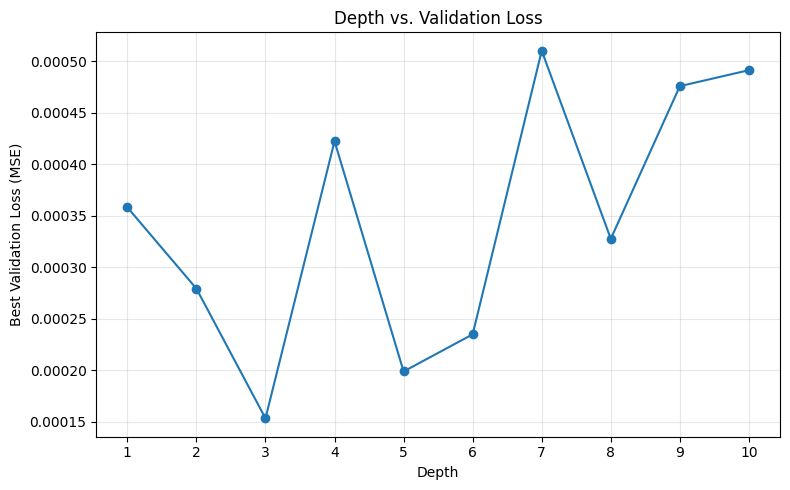

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(summary["depth"], summary["best_val_loss"], marker="o")
plt.xlabel("Depth")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Depth vs. Validation Loss")
plt.xticks(summary["depth"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
DEPTH = 3
WIDTHS = [32, 64, 128, 256, 512, 1024, 2048, 2560, 3072]

In [29]:
results = []

for width in WIDTHS:
    print(f"\n{'='*40}")
    print(f"Depth={DEPTH}, Width={width}")
    print(f"{'='*40}")

    torch.manual_seed(SEED)
    model = build_mlp(INPUT_DIM, OUTPUT_DIM, DEPTH, width, batch_norm=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

        if wait >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    results.append({"width": width, "best_val_loss": best_val, "best_state": best_state})
    print(f"  Best Val Loss: {best_val:.6f}")


Depth=3, Width=32
  Epoch   1 | Train: 0.058653 | Val: 0.007412 | Wait: 0
  Epoch   2 | Train: 0.007247 | Val: 0.003691 | Wait: 0
  Epoch   3 | Train: 0.005157 | Val: 0.002868 | Wait: 0
  Epoch   4 | Train: 0.004248 | Val: 0.001596 | Wait: 0
  Epoch   5 | Train: 0.003657 | Val: 0.001276 | Wait: 0
  Epoch   8 | Train: 0.002953 | Val: 0.000919 | Wait: 0
  Epoch  10 | Train: 0.002671 | Val: 0.000943 | Wait: 2
  Epoch  13 | Train: 0.002473 | Val: 0.000721 | Wait: 0
  Epoch  14 | Train: 0.002357 | Val: 0.000623 | Wait: 0
  Epoch  16 | Train: 0.002152 | Val: 0.000605 | Wait: 0
  Epoch  17 | Train: 0.002224 | Val: 0.000574 | Wait: 0
  Epoch  19 | Train: 0.002112 | Val: 0.000558 | Wait: 0
  Epoch  20 | Train: 0.002127 | Val: 0.000385 | Wait: 0
  Epoch  23 | Train: 0.002050 | Val: 0.000381 | Wait: 0
  Epoch  24 | Train: 0.001957 | Val: 0.000306 | Wait: 0
  Epoch  29 | Train: 0.001719 | Val: 0.000265 | Wait: 0
  Epoch  30 | Train: 0.001766 | Val: 0.000711 | Wait: 1
  Epoch  34 | Train: 0.001629

In [30]:
width_summary = pd.DataFrame([(r["width"], r["best_val_loss"]) for r in results],
                              columns=["width", "best_val_loss"])
print(width_summary.to_string(index=False))

best_w = width_summary.loc[width_summary["best_val_loss"].idxmin()]
print(f"\nBest width: {int(best_w['width'])} with val loss: {best_w['best_val_loss']:.6f}")

 width  best_val_loss
    32       0.000204
    64       0.000174
   128       0.000270
   256       0.000096
   512       0.000370
  1024       0.000728
  2048       0.001374
  2560       0.000117
  3072       0.000740

Best width: 256 with val loss: 0.000096


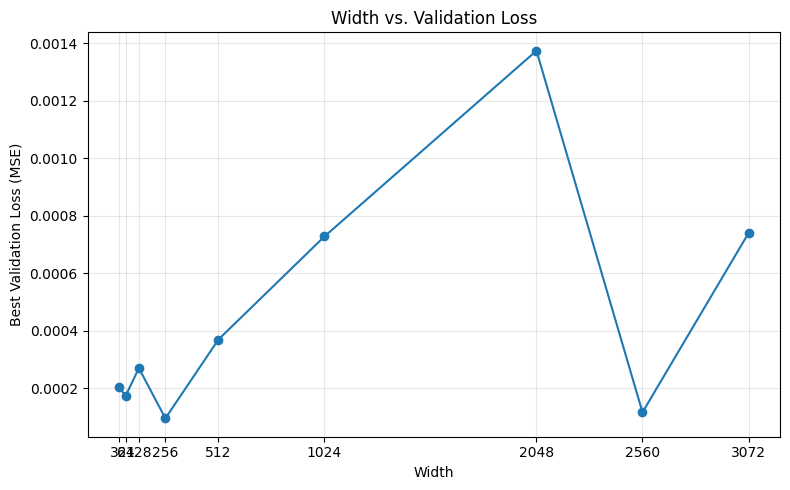

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(width_summary["width"], width_summary["best_val_loss"], marker="o")
plt.xlabel("Width")
plt.ylabel("Best Validation Loss (MSE)")
plt.title("Width vs. Validation Loss")
plt.xticks(width_summary["width"].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
GRID_DEPTHS = [2, 3, 4, 5, 6]
GRID_WIDTHS = [32, 512, 768, 1024, 1536, 2560]
print(f"Grid search: {len(GRID_DEPTHS)} depths x {len(GRID_WIDTHS)} widths = {len(GRID_DEPTHS)*len(GRID_WIDTHS)} combinations")

Grid search: 5 depths x 6 widths = 30 combinations


In [33]:
grid_results = []

for depth in GRID_DEPTHS:
    for width in GRID_WIDTHS:
        print(f"\n{'='*40}")
        print(f"Depth={depth}, Width={width}")
        print(f"{'='*40}")

        torch.manual_seed(SEED)
        model = build_mlp(INPUT_DIM, OUTPUT_DIM, depth, width, batch_norm=True).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        criterion = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        wait = 0

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item() * len(xb)
            train_loss /= len(train_loader.dataset)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(model(xb), yb).item() * len(xb)
            val_loss /= len(val_loader.dataset)

            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict().copy()
                wait = 0
            else:
                wait += 1

            if (epoch + 1) % 10 == 0 or wait == 0:
                print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

            if wait >= PATIENCE:
                print(f"  Early stop at epoch {epoch+1}")
                break

        grid_results.append({"depth": depth, "width": width, "best_val_loss": best_val, "best_state": best_state})
        print(f"  Best Val Loss: {best_val:.6f}")


Depth=2, Width=32
  Epoch   1 | Train: 0.093192 | Val: 0.007991 | Wait: 0
  Epoch   2 | Train: 0.007619 | Val: 0.004220 | Wait: 0
  Epoch   3 | Train: 0.005354 | Val: 0.003032 | Wait: 0
  Epoch   4 | Train: 0.004557 | Val: 0.002388 | Wait: 0
  Epoch   5 | Train: 0.003875 | Val: 0.002190 | Wait: 0
  Epoch   6 | Train: 0.003617 | Val: 0.001595 | Wait: 0
  Epoch   8 | Train: 0.003055 | Val: 0.001192 | Wait: 0
  Epoch   9 | Train: 0.002809 | Val: 0.000960 | Wait: 0
  Epoch  10 | Train: 0.002633 | Val: 0.000877 | Wait: 0
  Epoch  11 | Train: 0.002502 | Val: 0.000730 | Wait: 0
  Epoch  16 | Train: 0.002311 | Val: 0.000662 | Wait: 0
  Epoch  18 | Train: 0.002222 | Val: 0.000615 | Wait: 0
  Epoch  19 | Train: 0.002266 | Val: 0.000441 | Wait: 0
  Epoch  20 | Train: 0.002074 | Val: 0.000578 | Wait: 1
  Epoch  23 | Train: 0.002176 | Val: 0.000419 | Wait: 0
  Epoch  30 | Train: 0.002059 | Val: 0.000529 | Wait: 7
  Epoch  31 | Train: 0.001923 | Val: 0.000291 | Wait: 0
  Epoch  40 | Train: 0.001901

In [34]:
grid_df = pd.DataFrame([(r["depth"], r["width"], r["best_val_loss"]) for r in grid_results],
                       columns=["depth", "width", "best_val_loss"])
print(grid_df.sort_values("best_val_loss").to_string(index=False))

best_g = grid_df.loc[grid_df["best_val_loss"].idxmin()]
print(f"\nBest: depth={int(best_g['depth'])}, width={int(best_g['width'])}, val loss={best_g['best_val_loss']:.6f}")

 depth  width  best_val_loss
     5    768       0.000104
     6    512       0.000106
     3   2560       0.000117
     5    512       0.000131
     4   2560       0.000153
     6    768       0.000155
     6     32       0.000159
     4    512       0.000161
     5   1024       0.000166
     2    768       0.000196
     5   1536       0.000202
     3     32       0.000204
     4     32       0.000244
     6   1024       0.000274
     3    768       0.000275
     2     32       0.000291
     6   2560       0.000293
     3    512       0.000370
     2    512       0.000392
     5     32       0.000398
     4    768       0.000429
     5   2560       0.000434
     3   1536       0.000465
     6   1536       0.000480
     3   1024       0.000728
     2   1536       0.001041
     2   1024       0.001331
     4   1024       0.001431
     4   1536       0.001517
     2   2560       0.001775

Best: depth=5, width=768, val loss=0.000104


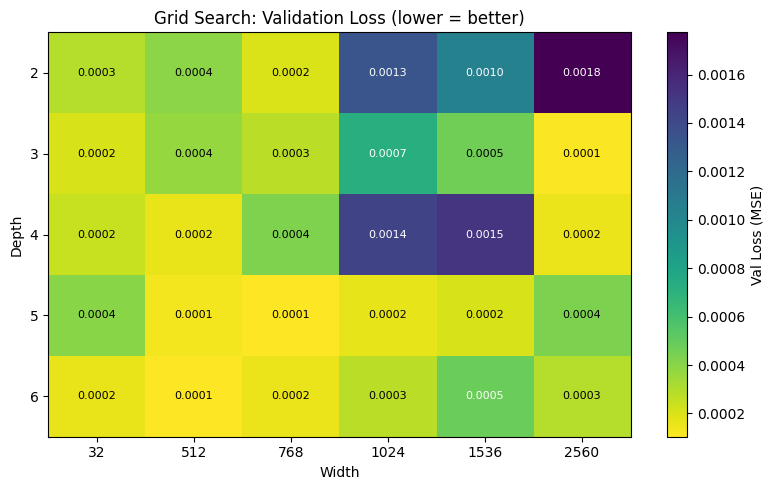

In [35]:
import numpy as np

heatmap = grid_df.pivot(index="depth", columns="width", values="best_val_loss")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap.values, cmap="viridis_r", aspect="auto")

ax.set_xticks(range(len(GRID_WIDTHS)))
ax.set_xticklabels(GRID_WIDTHS)
ax.set_yticks(range(len(GRID_DEPTHS)))
ax.set_yticklabels(GRID_DEPTHS)
ax.set_xlabel("Width")
ax.set_ylabel("Depth")
ax.set_title("Grid Search: Validation Loss (lower = better)")

for i in range(len(GRID_DEPTHS)):
    for j in range(len(GRID_WIDTHS)):
        val = heatmap.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=8,
                color="white" if val > heatmap.values.mean() else "black")

fig.colorbar(im, ax=ax, label="Val Loss (MSE)")
plt.tight_layout()
plt.show()

In [9]:
BEST_DEPTH = 5
BEST_WIDTH = 768

LRS = [5e-4, 1e-3, 5e-3, 1e-2]
BATCH_SIZES = [256, 512, 1024]
WEIGHT_DECAYS = [1e-4, 1e-3, 1e-2]

print(f"HP sweep: {len(LRS)} LRs x {len(BATCH_SIZES)} batch sizes x {len(WEIGHT_DECAYS)} weight decays = {len(LRS)*len(BATCH_SIZES)*len(WEIGHT_DECAYS)} runs")
print(f"Architecture: depth={BEST_DEPTH}, width={BEST_WIDTH}")
print("Scheduler: ReduceLROnPlateau (always on)")

HP sweep: 4 LRs x 3 batch sizes x 3 weight decays = 36 runs
Architecture: depth=5, width=768
Scheduler: ReduceLROnPlateau (always on)


In [10]:
from architectures.nn_build import build_mlp

hp_results = []

for bs in BATCH_SIZES:
    t_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=bs, shuffle=True)
    v_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=bs)

    for lr in LRS:
        for wd in WEIGHT_DECAYS:
            print(f"\n{'='*50}")
            print(f"BS={bs}, LR={lr}, WD={wd}")
            print(f"{'='*50}")

            torch.manual_seed(SEED)
            model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
            criterion = nn.MSELoss()

            best_val = float("inf")
            best_state = None
            wait = 0

            for epoch in range(EPOCHS):
                model.train()
                train_loss = 0.0
                for xb, yb in t_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, yb)
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    train_loss += loss.item() * len(xb)
                train_loss /= len(t_loader.dataset)

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for xb, yb in v_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        val_loss += criterion(model(xb), yb).item() * len(xb)
                val_loss /= len(v_loader.dataset)

                scheduler.step(val_loss)

                if val_loss < best_val:
                    best_val = val_loss
                    best_state = model.state_dict().copy()
                    wait = 0
                else:
                    wait += 1

                if (epoch + 1) % 10 == 0 or wait == 0:
                    print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Wait: {wait}")

                if wait >= PATIENCE:
                    print(f"  Early stop at epoch {epoch+1}")
                    break

            hp_results.append({"batch_size": bs, "lr": lr, "weight_decay": wd, "best_val_loss": best_val, "best_state": best_state})
            print(f"  Best Val Loss: {best_val:.6f}")


BS=256, LR=0.0005, WD=0.0001
  Epoch   1 | Train: 0.029878 | Val: 0.004660 | Wait: 0
  Epoch   2 | Train: 0.014864 | Val: 0.002605 | Wait: 0
  Epoch   4 | Train: 0.009930 | Val: 0.002517 | Wait: 0
  Epoch   6 | Train: 0.007951 | Val: 0.000639 | Wait: 0
  Epoch  10 | Train: 0.006648 | Val: 0.002044 | Wait: 4
  Epoch  11 | Train: 0.006211 | Val: 0.000468 | Wait: 0
  Epoch  14 | Train: 0.006035 | Val: 0.000421 | Wait: 0
  Epoch  20 | Train: 0.004805 | Val: 0.000344 | Wait: 0
  Epoch  26 | Train: 0.001258 | Val: 0.000240 | Wait: 0
  Epoch  30 | Train: 0.001018 | Val: 0.000410 | Wait: 4
  Epoch  35 | Train: 0.000443 | Val: 0.000238 | Wait: 0
  Epoch  40 | Train: 0.000414 | Val: 0.000433 | Wait: 5
  Early stop at epoch 45
  Best Val Loss: 0.000238

BS=256, LR=0.0005, WD=0.001
  Epoch   1 | Train: 0.029286 | Val: 0.004804 | Wait: 0
  Epoch   2 | Train: 0.014779 | Val: 0.001309 | Wait: 0
  Epoch   6 | Train: 0.007963 | Val: 0.000608 | Wait: 0
  Epoch  10 | Train: 0.006735 | Val: 0.002149 | Wa

In [11]:
hp_df = pd.DataFrame([(r["lr"], r["batch_size"], r["weight_decay"], r["best_val_loss"])
                      for r in hp_results],
                     columns=["lr", "batch_size", "weight_decay", "best_val_loss"])
print(hp_df.sort_values("best_val_loss").to_string(index=False))

best_hp = hp_df.loc[hp_df["best_val_loss"].idxmin()]
print(f"\nBest: LR={best_hp['lr']}, Batch={int(best_hp['batch_size'])}, WD={best_hp['weight_decay']}, Val Loss={best_hp['best_val_loss']:.6f}")

    lr  batch_size  weight_decay  best_val_loss
0.0100        1024        0.0100       0.000030
0.0050        1024        0.0001       0.000033
0.0100         512        0.0001       0.000041
0.0010        1024        0.0001       0.000049
0.0010        1024        0.0100       0.000052
0.0005        1024        0.0010       0.000069
0.0050         512        0.0100       0.000074
0.0100         512        0.0010       0.000074
0.0050         256        0.0010       0.000076
0.0050         512        0.0010       0.000096
0.0005        1024        0.0001       0.000106
0.0100         512        0.0100       0.000107
0.0010         512        0.0100       0.000122
0.0100         256        0.0010       0.000123
0.0100        1024        0.0001       0.000127
0.0050         256        0.0001       0.000140
0.0010         512        0.0010       0.000143
0.0100         256        0.0100       0.000144
0.0050         256        0.0100       0.000145
0.0100         256        0.0001       0

/var/folders/t7/fntycq1j1qj6w3tkrbztnsbw0000gp/T/ipykernel_22376/1625186723.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


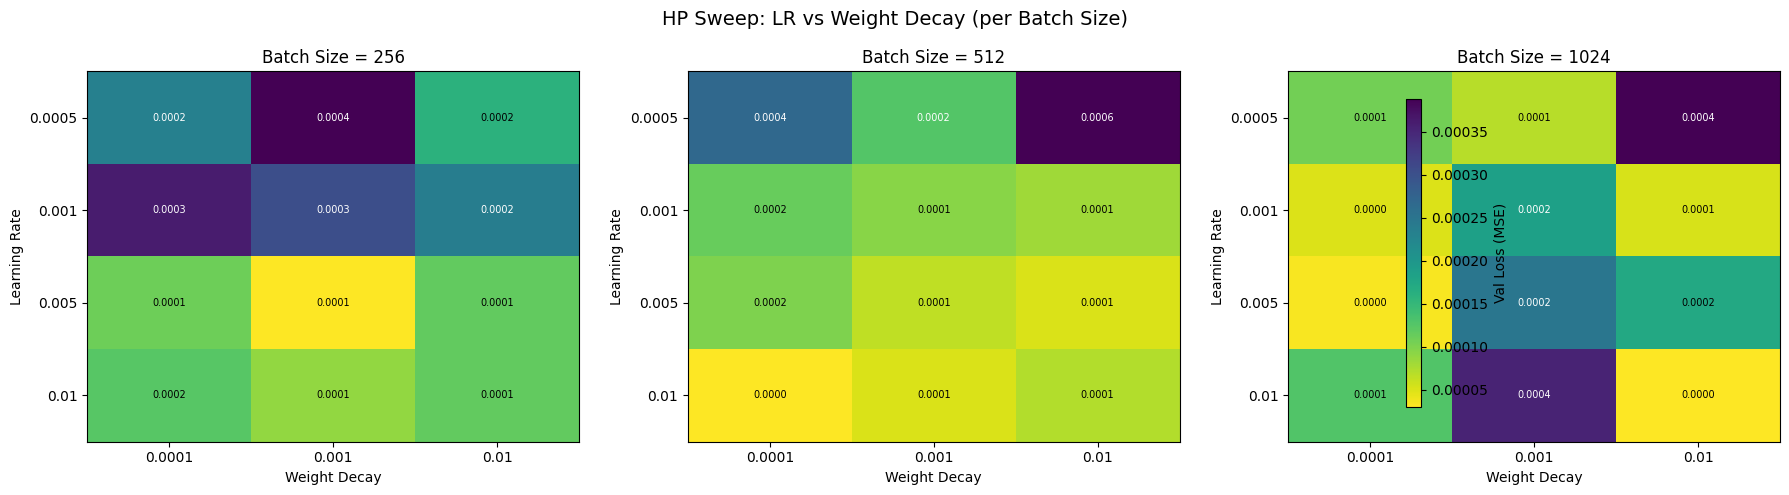

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bs in enumerate(BATCH_SIZES):
    subset = hp_df[hp_df["batch_size"] == bs]
    hm = subset.pivot(index="lr", columns="weight_decay", values="best_val_loss")

    im = axes[i].imshow(hm.values, cmap="viridis_r", aspect="auto")
    axes[i].set_xticks(range(len(WEIGHT_DECAYS)))
    axes[i].set_xticklabels(WEIGHT_DECAYS)
    axes[i].set_yticks(range(len(LRS)))
    axes[i].set_yticklabels(LRS)
    axes[i].set_xlabel("Weight Decay")
    axes[i].set_ylabel("Learning Rate")
    axes[i].set_title(f"Batch Size = {bs}")

    for r in range(len(LRS)):
        for c in range(len(WEIGHT_DECAYS)):
            val = hm.values[r, c]
            axes[i].text(c, r, f"{val:.4f}", ha="center", va="center", fontsize=7,
                         color="white" if val > hp_df["best_val_loss"].mean() else "black")

fig.colorbar(im, ax=axes, label="Val Loss (MSE)", shrink=0.8)
fig.suptitle("HP Sweep: LR vs Weight Decay (per Batch Size)", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
best_idx = hp_df["best_val_loss"].idxmin()
best_state = hp_results[best_idx]["best_state"]

final_model = build_mlp(INPUT_DIM, OUTPUT_DIM, BEST_DEPTH, BEST_WIDTH, batch_norm=True).to(device)
final_model.load_state_dict(best_state)
final_model.eval()
print(f"Loaded best model: LR={hp_df.loc[best_idx, 'lr']}, BS={int(hp_df.loc[best_idx, 'batch_size'])}, WD={hp_df.loc[best_idx, 'weight_decay']}")
print(f"Val loss: {hp_df.loc[best_idx, 'best_val_loss']:.6f}")

Loaded best model: LR=0.01, BS=1024, WD=0.01
Val loss: 0.000030


In [15]:
import numpy as np

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    preds_scaled = final_model(X_test_t).cpu().numpy()

preds = scaler_y.inverse_transform(preds_scaled).ravel()
y_true = y_test.values.ravel()

# Convert back to actual price: price_convertible = expm1(price_normalized)
preds_price = np.expm1(preds)
y_true_price = np.expm1(y_true)

mae = np.abs(preds_price - y_true_price).mean()
rmse = np.sqrt(((preds_price - y_true_price) ** 2).mean())

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'MAE':<10} {mae:>12.4f}")
print(f"{'RMSE':<10} {rmse:>12.4f}")

Metric            Value
------------------------
MAE              7.0295
RMSE             9.6767


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true_price, preds_price)

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'R²':<10} {r2:>12.6f}")

Metric            Value
------------------------
R²             0.999920


In [17]:
import matplotlib.pyplot as plt

test_features = df.loc[y_test.index]

analysis = pd.DataFrame({
    "price_true": y_true_price,
    "price_pred": preds_price,
    "price_err": np.abs(preds_price - y_true_price),
    "maturity_years": test_features["maturity_years"].values,
    "log_moneyness": test_features["log_moneyness"].values,
    "credit_spread": test_features["credit_spread"].values,
})

# Price regime buckets (dollar terms)
analysis["price_regime"] = pd.cut(analysis["price_true"],
    bins=[0, 200, 500, 1000, 2000, 6000],
    labels=["< $200", "$200-500", "$500-1k", "$1k-2k", "> $2k"])

# Maturity buckets
analysis["maturity"] = pd.cut(analysis["maturity_years"],
    bins=[0, 2, 5, 7, 10],
    labels=["< 2y", "2-5y", "5-7y", "> 7y"])

# Moneyness buckets
analysis["moneyness"] = pd.cut(analysis["log_moneyness"],
    bins=[-3, 0, 1, 2, 3, 5],
    labels=["OTM", "Near ATM", "Mild ITM", "ITM", "Deep ITM"])

# Credit risk buckets (spread in bps)
analysis["credit_risk"] = pd.cut(analysis["credit_spread"],
    bins=[0, 0.03, 0.06, 0.10, 0.15],
    labels=["Low (<300bp)", "Med (300-600bp)", "High (600-1000bp)", "Very High (>1000bp)"])

print("=== Price Error ($) by Price Regime ===")
regime_stats = analysis.groupby("price_regime", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(regime_stats.to_string(index=False))

print("\n=== Price Error ($) by Maturity ===")
mat_stats = analysis.groupby("maturity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mat_stats.to_string(index=False))

print("\n=== Price Error ($) by Moneyness ===")
mon_stats = analysis.groupby("moneyness", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mon_stats.to_string(index=False))

print("\n=== Price Error ($) by Credit Risk ===")
credit_stats = analysis.groupby("credit_risk", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(credit_stats.to_string(index=False))

=== Price Error ($) by Price Regime ===
price_regime  count       MAE      RMSE       R2
      < $200  19660  1.184643  1.628622 0.998401
    $200-500  40147  3.073656  3.492506 0.998379
     $500-1k  54529  3.973476  4.434886 0.999051
      $1k-2k  69424  4.593317  5.463815 0.999638
       > $2k  66240 16.230814 17.255362 0.999371

=== Price Error ($) by Maturity ===
maturity  count      MAE     RMSE
    < 2y  27967 6.901910 9.555578
    2-5y  83425 6.945564 9.574997
    5-7y  55377 7.073176 9.716504
    > 7y  83231 7.127426 9.791351

=== Price Error ($) by Moneyness ===
moneyness  count       MAE      RMSE
      OTM   7786  0.816338  1.112660
 Near ATM  22455  1.721940  2.145034
 Mild ITM  58351  4.067081  4.449639
      ITM  95659  4.245418  5.113513
 Deep ITM  65749 16.257595 17.283325

=== Price Error ($) by Credit Risk ===
        credit_risk  count     MAE     RMSE       R2
       Low (<300bp)  43153 6.89285 9.530159 0.999922
    Med (300-600bp)  51640 6.94523 9.573058 0.999921


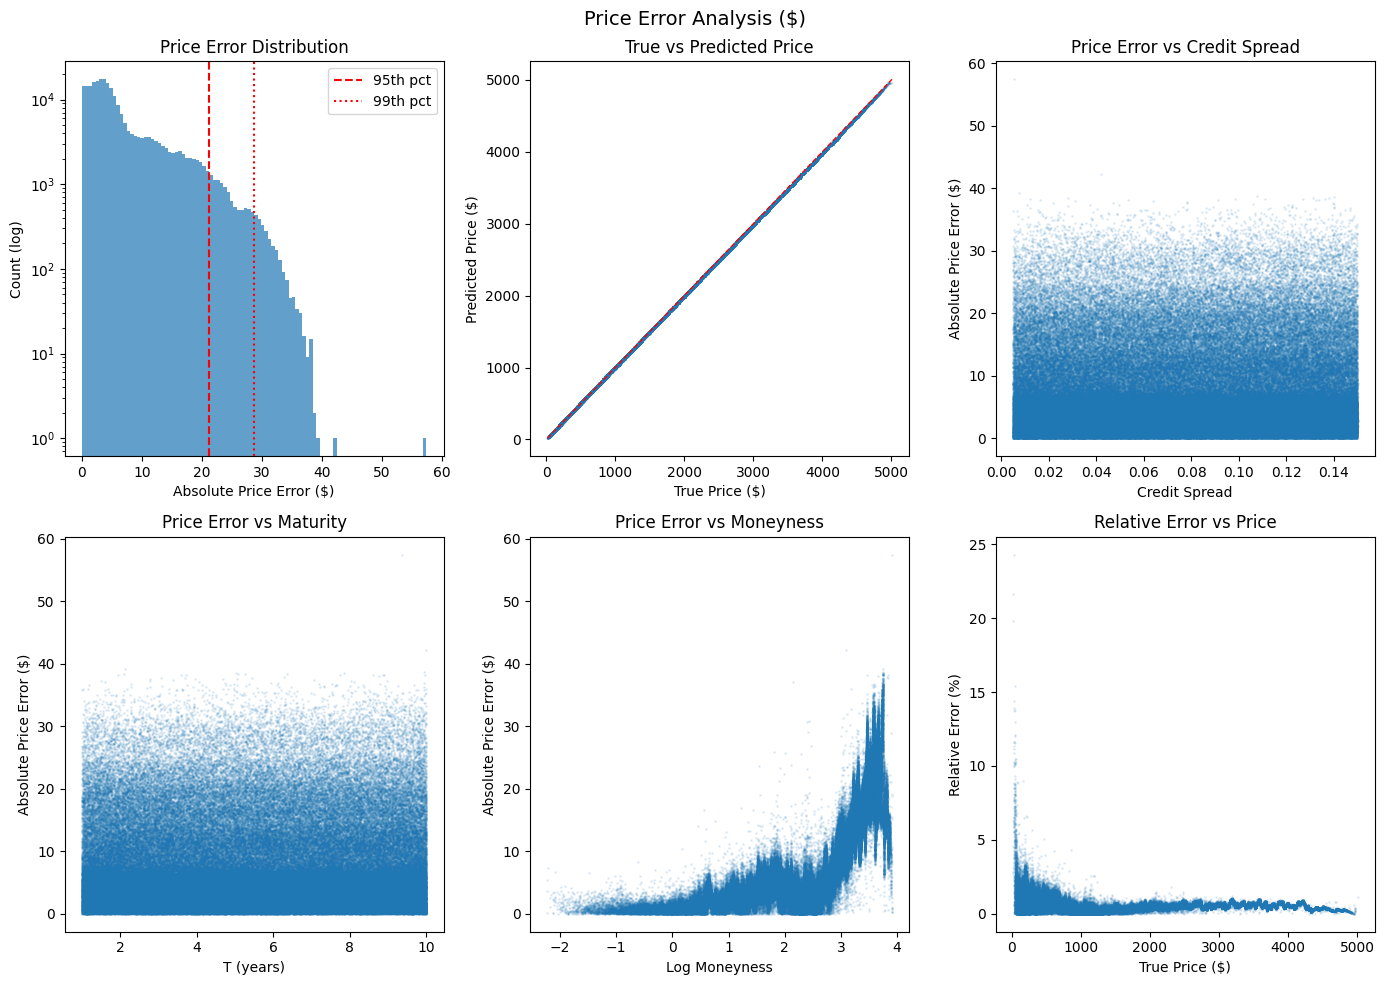

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Error distribution (log scale)
axes[0, 0].hist(analysis["price_err"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Absolute Price Error ($)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Price Error Distribution")
axes[0, 0].axvline(analysis["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
axes[0, 0].axvline(analysis["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
axes[0, 0].legend()

# 2. True vs Predicted scatter
axes[0, 1].scatter(analysis["price_true"], analysis["price_pred"], s=1, alpha=0.1)
lims = [analysis["price_true"].min(), analysis["price_true"].max()]
axes[0, 1].plot(lims, lims, "r--", lw=1)
axes[0, 1].set_xlabel("True Price ($)")
axes[0, 1].set_ylabel("Predicted Price ($)")
axes[0, 1].set_title("True vs Predicted Price")

# 3. Error vs maturity
axes[1, 0].scatter(analysis["maturity_years"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 0].set_xlabel("T (years)")
axes[1, 0].set_ylabel("Absolute Price Error ($)")
axes[1, 0].set_title("Price Error vs Maturity")

# 4. Error vs moneyness
axes[1, 1].scatter(analysis["log_moneyness"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 1].set_xlabel("Log Moneyness")
axes[1, 1].set_ylabel("Absolute Price Error ($)")
axes[1, 1].set_title("Price Error vs Moneyness")

# 5. Error vs credit spread
axes[0, 2].scatter(analysis["credit_spread"], analysis["price_err"], s=1, alpha=0.1)
axes[0, 2].set_xlabel("Credit Spread")
axes[0, 2].set_ylabel("Absolute Price Error ($)")
axes[0, 2].set_title("Price Error vs Credit Spread")

# 6. Relative error (%) vs price
pct_err = analysis["price_err"] / analysis["price_true"] * 100
axes[1, 2].scatter(analysis["price_true"], pct_err, s=1, alpha=0.1)
axes[1, 2].set_xlabel("True Price ($)")
axes[1, 2].set_ylabel("Relative Error (%)")
axes[1, 2].set_title("Relative Error vs Price")

plt.suptitle("Price Error Analysis ($)", fontsize=14)
plt.tight_layout()
plt.show()


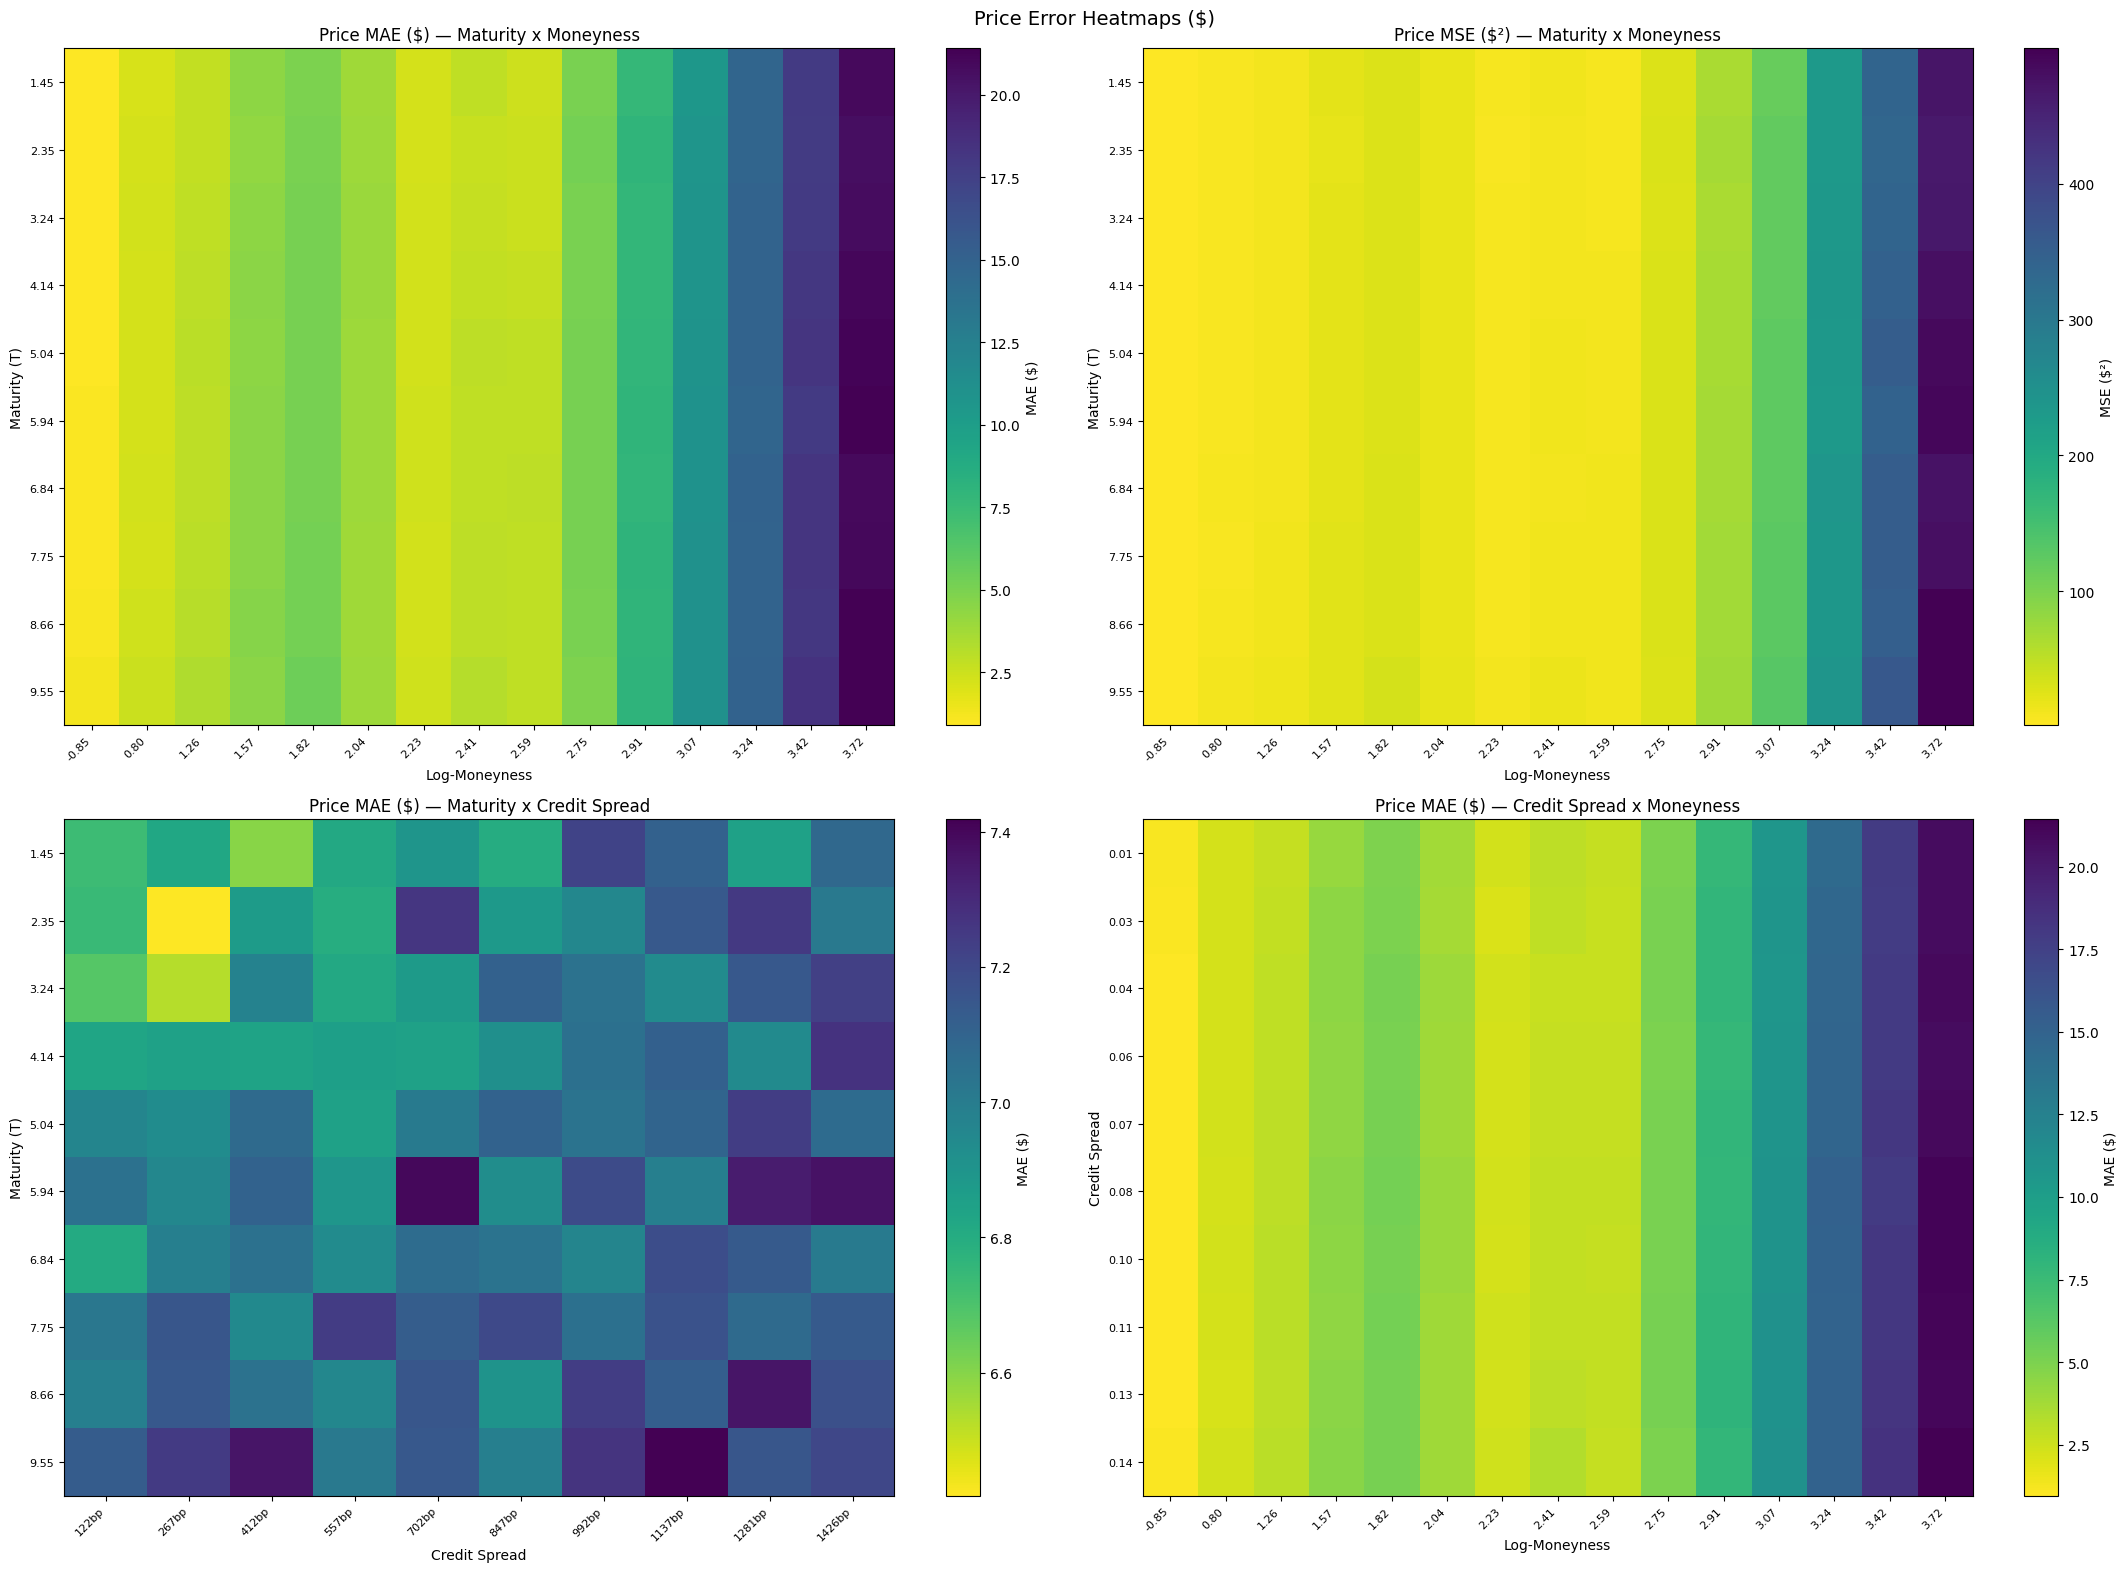

In [19]:
moneyness = analysis["log_moneyness"].values
maturity = analysis["maturity_years"].values
credit = analysis["credit_spread"].values
err_abs = analysis["price_err"].values
err_sq = err_abs ** 2

n_m, n_t, n_c = 15, 10, 10
m_edges = np.percentile(moneyness, np.linspace(0, 100, n_m + 1))
t_edges = np.percentile(maturity, np.linspace(0, 100, n_t + 1))
c_edges = np.percentile(credit, np.linspace(0, 100, n_c + 1))

m_idx = np.clip(np.digitize(moneyness, m_edges[1:-1]), 0, n_m - 1)
t_idx = np.clip(np.digitize(maturity, t_edges[1:-1]), 0, n_t - 1)
c_idx = np.clip(np.digitize(credit, c_edges[1:-1]), 0, n_c - 1)

def build_grid(row_idx, col_idx, n_row, n_col, vals):
    grid = np.full((n_row, n_col), np.nan)
    for ri in range(n_row):
        for ci in range(n_col):
            mask = (row_idx == ri) & (col_idx == ci)
            if mask.sum() > 0:
                grid[ri, ci] = vals[mask].mean()
    return grid

grid_mae_mm = build_grid(t_idx, m_idx, n_t, n_m, err_abs)
grid_mse_mm = build_grid(t_idx, m_idx, n_t, n_m, err_sq)
grid_mae_mc = build_grid(t_idx, c_idx, n_t, n_c, err_abs)
grid_mae_cm = build_grid(c_idx, m_idx, n_c, n_m, err_abs)

m_mids = 0.5 * (m_edges[:-1] + m_edges[1:])
t_mids = 0.5 * (t_edges[:-1] + t_edges[1:])
c_mids = 0.5 * (c_edges[:-1] + c_edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

configs = [
    (axes[0, 0], grid_mae_mm, "Price MAE ($) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MAE ($)", n_m, n_t, "moneyness"),
    (axes[0, 1], grid_mse_mm, "Price MSE ($²) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MSE ($²)", n_m, n_t, "moneyness"),
    (axes[1, 0], grid_mae_mc, "Price MAE ($) — Maturity x Credit Spread",
     c_mids, t_mids, "Credit Spread", "Maturity (T)", "MAE ($)", n_c, n_t, "credit"),
    (axes[1, 1], grid_mae_cm, "Price MAE ($) — Credit Spread x Moneyness",
     m_mids, c_mids, "Log-Moneyness", "Credit Spread", "MAE ($)", n_m, n_c, "moneyness"),
]

for ax, grid, title, x_mids, y_mids, xlabel, ylabel, cbar_label, nx, ny, xtype in configs:
    im = ax.imshow(grid, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(nx))
    if xtype == "credit":
        ax.set_xticklabels([f"{int(v*10000)}bp" for v in x_mids], rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticklabels([f"{v:.2f}" for v in x_mids], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(ny))
    ax.set_yticklabels([f"{v:.2f}" for v in y_mids], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)

plt.suptitle("Price Error Heatmaps ($)", fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
import os
import pickle

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    "model_state_dict": final_model.state_dict(),
    "input_dim": INPUT_DIM,
    "output_dim": OUTPUT_DIM,
    "depth": BEST_DEPTH,
    "width": BEST_WIDTH,
}, os.path.join(save_dir, "baseline_fnn.pt"))

with open(os.path.join(save_dir, "scaler_X.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)
with open(os.path.join(save_dir, "scaler_y.pkl"), "wb") as f:
    pickle.dump(scaler_y, f)

print(f"Model saved to {save_dir}/baseline_fnn.pt")
print(f"Scalers saved to {save_dir}/scaler_X.pkl, scaler_y.pkl")

Model saved to ../models/baseline_fnn.pt
Scalers saved to ../models/scaler_X.pkl, scaler_y.pkl
